In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc3 as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

In [2]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [15],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": gabor_locations,
    "orientations": [0.0, np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

gabor_set = GaborSet(**gabor_params)

In [7]:
total_param_count = np.prod(gabor_set.num_params())
param_combos = [gabor_set.params_dict_from_idx(idx) for idx in range(total_param_count)]
valid_params_gabors = [
    (param_combos[idx], gabor_set.stimulus_from_idx(idx))
    for idx in range(total_param_count)
    if not (
        param_combos[idx]["orientation"] == 0.0
        and param_combos[idx]["location"] == (25, 25)
    )
]

In [11]:
valid_params_gabors = sorted(valid_params_gabors, key=lambda x: x[0]["orientation"])

In [12]:
valid_gabors = np.array([gabor for _, gabor in valid_params_gabors])
valid_orientations = np.array(
    [param["orientation"] for param, _ in valid_params_gabors]
)

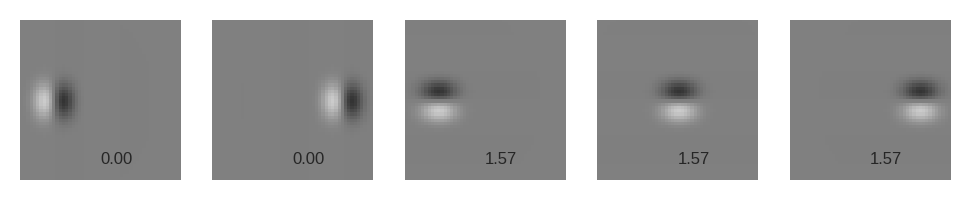

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=5, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = valid_gabors[idx]
    orientation = valid_orientations[idx]
    ax.imshow(gabor, cmap="gray", vmin=-1, vmax=1)
    # print orientation in small font in the top of each axis
    ax.text(0.5, 0.1, f"{orientation:.2f}", transform=ax.transAxes, fontsize=6)
    ax.axis("off")